# Итоговый проект: «От дерева решений к ансамблю и кластеризации»

## Задание

**Проект** поможет увидеть, как на практике решаются задачи анализа данных — от простых правил до более сложных алгоритмов.

Вы научитесь строить алгоритмы, которые сами находят закономерности в данных, и поймёте, как такие методы применяются, например, при разделении клиентов на группы, прогнозе событий или оценке качества решений.

Проект даст вам опыт «взрослой» аналитической работы, когда нужно не просто обработать таблицу, а объяснить, почему модель принимает именно такие решения.

**Цель проекта**

Цель проекта — закрепить понимание принципов работы алгоритмов деревьев решений, ансамблей и кластеризации через собственную реализацию и анализ их поведения на данных.

В ходе проекта вы:

* реализуете базовые версии алгоритмов с нуля, используя numpy и pandas;
* проведёте эксперименты с параметрами и сравните результаты с реализациями из sklearn;
* научитесь интерпретировать результаты и визуализировать их.

**Формат выполнения**
1. Проект выполняется индивидуально.
2. Результат — Jupyter Notebook (.ipynb):
    * с описанием цели и задач проекта;
    * кодом с комментариями;
    * визуализациями и таблицами;
    * краткими выводами по каждому этапу.
3. В конце ноутбука добавьте общий вывод: чему вы научились и какие особенности алгоритмов заметили.

## Этапы проекта

### Этап 1. Реализация дерева решений (15 баллов)
На этом этапе вы создаёте простую реализацию дерева решений для задачи классификации.

#### Что нужно сделать

1. Сгенерируйте небольшой набор данных (100–300 наблюдений) с помощью функции:

```from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=200,
    n_features=2,  # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)
```
2. Преобразуйте данные в pandas.DataFrame.

3. Реализуйте функции:

* расчёта критерия Джини или энтропии;
* поиска наилучшего разбиения по признаку;
* рекурсивного построения дерева с ограничением по глубине (max_depth) или по числу объектов в узле (min_samples_split);
* предсказания для новых наблюдений.

#### Тестирование модели
1. Разделите данные на обучающую и тестовую выборки (например, с помощью train_test_split, зафиксировав random_state=42 для воспроизводимости).
2. Сравните результаты своей реализации с DecisionTreeClassifier из sklearn. Разрешается использовать этот класс только для сверки корректности.
3. Постройте график границ решений (если данных 2D) с помощью matplotlib.

#### Результат
* Таблица с точностью (accuracy) на обучении и тесте.
* Визуализация дерева или границ решений.
* Краткий комментарий о различиях вашей реализации и sklearn.


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [14]:
# 1. Генерация данных
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
    n_classes=2 # Явно указываем 2 класса для бинарной классификации
)

# 2. Преобразование в pandas.DataFrame
# Объединяем признаки X и целевую переменную y в один DataFrame
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y
display(df)

,feature_1,feature_2,target
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,0
3,-2.585395,0.963532,0
4,1.372246,0.440695,1
...,...,...,...
195,-0.435396,0.715716,0
196,1.040417,1.108613,1
197,1.883798,0.782433,0
198,1.829367,1.542978,1


In [11]:
display(df.target.value_counts())

target
1    100
0    100
Name: count, dtype: int64

In [ ]:
print(f"Размер сгенерированного набора данных: {df.shape}")
print(df.head())

# --- Реализация дерева решений ---

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    # 3.1. Расчет критерия Джини
    @staticmethod
    def _gini_impurity(y):
        """Рассчитывает критерий Джини для заданного набора меток."""
        if len(y) == 0:
            return 0
        p = np.bincount(y) / len(y)
        # Сумма квадратов вероятностей для каждого класса
        gini = 1.0 - np.sum(p**2)
        return gini

    # 3.2. Поиск наилучшего разбиения по признаку
    def _find_best_split(self, X, y):
        """Находит наилучшее пороговое значение и признак для разбиения данных."""
        best_gini = 1.0
        best_split = None
        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None

        current_gini = self._gini_impurity(y)

        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            # Уникальные значения признака в качестве возможных порогов
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                # Разделение данных на левый и правый поднаборы
                left_mask = feature_values <= threshold
                right_mask = feature_values > threshold
                
                # Избегаем пустых разбиений
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Расчет взвешенного Gini после разбиения
                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                
                weight_left = len(y_left) / n_samples
                weight_right = len(y_right) / n_samples
                gini_after_split = weight_left * gini_left + weight_right * gini_right

                # Расчет снижения неопределенности (Information Gain)
                information_gain = current_gini - gini_after_split

                if information_gain > 0 and gini_after_split < best_gini:
                    best_gini = gini_after_split
                    best_split = {
                        'feature_idx': feature_idx,
                        'threshold': threshold,
                        'left_mask': left_mask,
                        'right_mask': right_mask
                    }

        return best_split

    # 3.3. Рекурсивное построение дерева
    def _build_tree_recursive(self, X, y, depth=0):
        """Рекурсивно строит дерево решений."""
        
        # Условие останова 1: достигнута максимальная глубина
        if self.max_depth is not None and depth >= self.max_depth:
            # Превращаем узел в лист, предсказывая самый частый класс
            return {'leaf': True, 'class': np.bincount(y).argmax()}

        # Условие останова 2: недостаточно объектов для разбиения
        if len(y) < self.min_samples_split:
             return {'leaf': True, 'class': np.bincount(y).argmax()}

        split = self._find_best_split(X, y)
        
        # Условие останова 3: невозможно найти хорошее разбиение (все объекты одного класса или признаки неразделимы)
        if split is None:
            return {'leaf': True, 'class': np.bincount(y).argmax()}

        # Если разбиение найдено, создаем внутренний узел и продолжаем рекурсию
        left_branch = self._build_tree_recursive(X[split['left_mask']], y[split['left_mask']], depth + 1)
        right_branch = self._build_tree_recursive(X[split['right_mask']], y[split['right_mask']], depth + 1)

        return {
            'leaf': False,
            'feature_idx': split['feature_idx'],
            'threshold': split['threshold'],
            'left': left_branch,
            'right': right_branch
        }

    def fit(self, X, y):
        """Запускает процесс обучения дерева."""
        # Если X это DataFrame, преобразуем его в numpy array
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
            
        self.tree = self._build_tree_recursive(X, y, depth=0)
        return self

    # 3.4. Предсказание для новых наблюдений
    def _predict_one_sample(self, sample, node):
        """Проходит по дереву для одного образца."""
        if node['leaf']:
            return node['class']
        
        # Проверяем значение признака образца относительно порога узла
        if sample[node['feature_idx']] <= node['threshold']:
            return self._predict_one_sample(sample, node['left'])
        else:
            return self._predict_one_sample(sample, node['right'])

    def predict(self, X):
        """Делает предсказания для набора наблюдений."""
        if self.tree is None:
            raise Exception("Модель не обучена. Вызовите метод fit первым.")
            
        # Если X это DataFrame, преобразуем его в numpy array
        if isinstance(X, pd.DataFrame):
            X = X.values

        predictions = [self._predict_one_sample(sample, self.tree) for sample in X]
        return np.array(predictions)

# --- Использование реализованного дерева ---

# Разделяем данные на обучающую и тестовую выборки вручную
# (В реальных задачах лучше использовать train_test_split из sklearn)
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

X_train = train_df[['feature_1', 'feature_2']]
y_train = train_df['target']
X_test = test_df[['feature_1', 'feature_2']]
y_test = test_df['target']

# Инициализация и обучение дерева с ограничением глубины
print("\nНачинаем обучение дерева...")
tree_classifier = DecisionTree(max_depth=5, min_samples_split=10)
tree_classifier.fit(X_train, y_train)
print("Обучение завершено.")

# Предсказание на тестовом наборе
predictions = tree_classifier.predict(X_test)

# Оценка точности (accuracy)
accuracy = np.mean(predictions == y_test.values)
print(f"\nПредсказания для первых 5 тестовых образцов: {predictions[:5]}")
print(f"Фактические метки для первых 5 тестовых образцов: {y_test.values[:5]}")
print(f"Точность (Accuracy) на тестовой выборке: {accuracy:.4f}")

Размер сгенерированного набора данных: (200, 3)
   feature_1  feature_2  target
0   1.689767  -1.408241       1
1   1.530287  -1.459848       1
2  -1.175042  -1.447633       0
3  -2.585395   0.963532       0
4   1.372246   0.440695       1

Начинаем обучение дерева...
Обучение завершено.

Предсказания для первых 5 тестовых образцов: [1 1 0 0 1]
Фактические метки для первых 5 тестовых образцов: [1 1 0 0 1]
Точность (Accuracy) на тестовой выборке: 0.8750


Первые 5 строк датафрейма:
   feature_1  feature_2  target
0   1.689767  -1.408241       1
1   1.530287  -1.459848       1
2  -1.175042  -1.447633       0
3  -2.585395   0.963532       0
4   1.372246   0.440695       1

Точность на тестовой выборке: 0.750



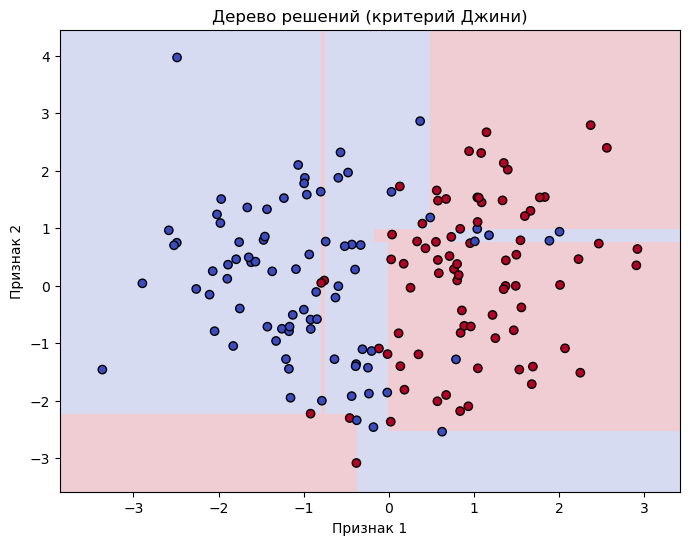

Предсказания для 5 новых наблюдений:
  Наблюдение 1: признаки [ 0.497 -0.138] -> класс 1
  Наблюдение 2: признаки [0.648 1.523] -> класс 1
  Наблюдение 3: признаки [-0.234 -0.234] -> класс 0
  Наблюдение 4: признаки [1.579 0.767] -> класс 1
  Наблюдение 5: признаки [-0.469  0.543] -> класс 0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==================== 1. Генерация данных ====================
X, y = make_classification(
    n_samples=200,
    n_features=2,          # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# ==================== 2. Преобразование в pandas.DataFrame ====================
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y
print("Первые 5 строк датафрейма:")
print(df.head())
print()

# Разделим данные на обучающую и тестовую выборки (опционально, для демонстрации)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== 3. Реализация дерева решений ====================
class Node:
    """Узел дерева."""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx   # индекс признака, по которому происходит разбиение
        self.threshold = threshold       # пороговое значение
        self.left = left                 # левое поддерево
        self.right = right               # правое поддерево
        self.value = value               # значение в листовом узле (класс)

class DecisionTree:
    """Классификатор дерева решений с поддержкой критериев Джини и энтропии."""
    def __init__(self, criterion='gini', max_depth=5, min_samples_split=2):
        """
        :param criterion: 'gini' или 'entropy'
        :param max_depth: максимальная глубина дерева
        :param min_samples_split: минимальное количество образцов для разделения узла
        """
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        """Построение дерева по обучающим данным."""
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        """Рекурсивное построение дерева."""
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Условия остановки рекурсии
        if (depth >= self.max_depth
                or n_labels == 1
                or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Поиск наилучшего разбиения
        best_feat, best_thresh = self._best_split(X, y)

        # Если не удалось найти разбиение (все gain = 0), создаём лист
        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Разделение данных
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)

        return Node(feature_idx=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y):
        """Поиск наилучшего признака и порога для разбиения."""
        best_gain = -1
        best_feat, best_thresh = None, None

        for feat_idx in range(X.shape[1]):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = threshold

        return best_feat, best_thresh

    def _information_gain(self, y, X_column, split_thresh):
        """Расчёт прироста информации (gain) для заданного признака и порога."""
        # Неопределённость родительского узла
        parent_impurity = self._impurity(y)

        # Разделение выборки
        left_idxs, right_idxs = self._split(X_column, split_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Взвешенная неопределённость дочерних узлов
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        child_impurity = (n_l / n) * self._impurity(y[left_idxs]) + (n_r / n) * self._impurity(y[right_idxs])

        # Прирост информации
        gain = parent_impurity - child_impurity
        return gain

    def _impurity(self, y):
        """Расчёт неопределённости (Джини или энтропии) для набора меток."""
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)

        if self.criterion == 'gini':
            # Критерий Джини
            return 1.0 - np.sum(probs ** 2)
        elif self.criterion == 'entropy':
            # Энтропия Шеннона
            return -np.sum(probs * np.log2(probs + 1e-10))  # +1e-10 для избежания log(0)
        else:
            raise ValueError("Критерий должен быть 'gini' или 'entropy'")

    def _split(self, X_column, split_thresh):
        """Разделение индексов по пороговому значению."""
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        """Возвращает наиболее частую метку в выборке."""
        _, counts = np.unique(y, return_counts=True)
        return max(zip(_, counts), key=lambda x: x[1])[0]

    def predict(self, X):
        """Предсказание для новых наблюдений."""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """Рекурсивный обход дерева для одного наблюдения."""
        if node.value is not None:   # листовой узел
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def visualize_boundary(self, X, y, title='Граница решения дерева'):
        """Визуализация границы решения (только для 2D-данных)."""
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))

        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(8, 6))
        plt.pcolormesh(xx, yy, Z, cmap='coolwarm', alpha=0.2)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())
        plt.xlabel('Признак 1')
        plt.ylabel('Признак 2')
        plt.title(title)
        plt.show()

# ==================== 4. Обучение и оценка модели ====================
# Создаём экземпляр дерева с критерием Джини (можно заменить на 'entropy')
tree = DecisionTree(criterion='gini', max_depth=5, min_samples_split=5)
tree.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность на тестовой выборке: {accuracy:.3f}')
print()

# ==================== 5. Визуализация границы решения (опционально) ====================
tree.visualize_boundary(X_train, y_train, title='Дерево решений (критерий Джини)')

# ==================== 6. Пример предсказания для новых наблюдений ====================
# Создадим 5 случайных наблюдений
np.random.seed(42)
new_X = np.random.randn(5, 2)
new_pred = tree.predict(new_X)
print('Предсказания для 5 новых наблюдений:')
for i, (x, pred) in enumerate(zip(new_X, new_pred)):
    print(f'  Наблюдение {i+1}: признаки {x.round(3)} -> класс {pred}')

РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
              Модель  Accuracy на обучении  Accuracy на тесте
    Кастомное дерево              0.885714           0.833333
Sklearn DecisionTree              0.885714           0.833333



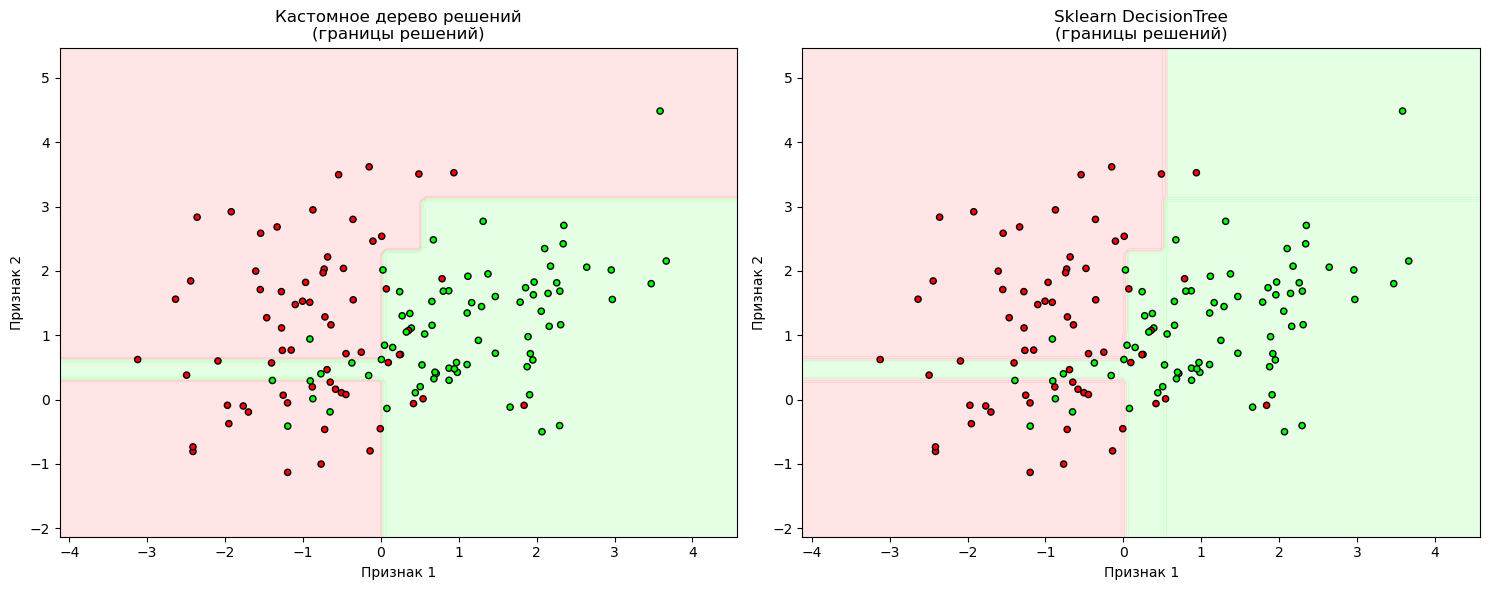


СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ
[feature1 <= -0.000]
  [feature2 <= 0.569]
    [feature2 <= 0.280]
      Лист: класс = 0
    [feature2 > 0.280]
      Лист: класс = 1
  [feature2 > 0.569]
    [feature2 <= 1.027]
      Лист: класс = 0
    [feature2 > 1.027]
      Лист: класс = 0
[feature1 > -0.000]
  [feature1 <= 0.552]
    [feature2 <= 2.276]
      Лист: класс = 1
    [feature2 > 2.276]
      Лист: класс = 0
  [feature1 > 0.552]
    [feature2 <= 3.148]
      Лист: класс = 1
    [feature2 > 3.148]
      Лист: класс = 0

АНАЛИЗ РЕЗУЛЬТАТОВ

Различия между кастомной реализацией и sklearn DecisionTree:

1. **Критерии остановки**: 
   - Кастомное дерево использует простые условия (max_depth, min_samples_split, чистота узла)
   - Sklearn имеет более сложную систему критериев (min_impurity_decrease и др.)

2. **Поиск порогов**:
   - Наша реализация проверяет средние значения между соседними точками
   - Sklearn использует более эффективные алгоритмы (быстрая сортировка)

3. **Обработка ка

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Генерация данных
np.random.seed(42)
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Преобразование в DataFrame
df = pd.DataFrame(X, columns=['feature1', 'feature2'])
df['target'] = y

# 3. Реализация дерева решений с нуля
class Node:
    """Узел дерева решений"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx  # Индекс признака для разбиения
        self.threshold = threshold      # Пороговое значение
        self.left = left                # Левый потомок (<= threshold)
        self.right = right              # Правый потомок (> threshold)
        self.value = value              # Значение в листе (если это лист)

class CustomDecisionTree:
    """Кастомная реализация дерева решений"""
    
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None
    
    def _gini(self, y):
        """Вычисление критерия Джини"""
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def _entropy(self, y):
        """Вычисление энтропии"""
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    def _information_gain(self, y, y_left, y_right, criterion_func):
        """Вычисление прироста информации"""
        p = len(y_left) / len(y)
        parent_impurity = criterion_func(y)
        children_impurity = p * criterion_func(y_left) + (1 - p) * criterion_func(y_right)
        return parent_impurity - children_impurity
    
    def _best_split(self, X, y):
        """Поиск наилучшего разбиения"""
        best_gain = -1
        best_feature_idx = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            
            # Рассматриваем пороги как средние между соседними значениями
            thresholds = []
            for i in range(len(unique_values) - 1):
                thresholds.append((unique_values[i] + unique_values[i + 1]) / 2)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = feature_values > threshold
                
                if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                    continue
                
                if self.criterion == 'gini':
                    gain = self._information_gain(y, y[left_mask], y[right_mask], self._gini)
                else:  # entropy
                    gain = self._information_gain(y, y[left_mask], y[right_mask], self._entropy)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature_idx = feature_idx
                    best_threshold = threshold
        
        return best_feature_idx, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        """Рекурсивное построение дерева"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(np.unique(y)) == 1):
            return Node(value=np.argmax(np.bincount(y)))
        
        # Поиск наилучшего разбиения
        feature_idx, threshold, gain = self._best_split(X, y)
        
        # Если не удалось найти разбиение (gain <= 0)
        if feature_idx is None or gain <= 0:
            return Node(value=np.argmax(np.bincount(y)))
        
        # Разделение данных
        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold
        
        # Рекурсивное построение поддеревьев
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature_idx=feature_idx, threshold=threshold, 
                   left=left_subtree, right=right_subtree)
    
    def fit(self, X, y):
        """Обучение дерева"""
        self.root = self._build_tree(X, y)
    
    def _predict_one(self, x, node):
        """Предсказание для одного наблюдения"""
        if node.value is not None:
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
    
    def predict(self, X):
        """Предсказание для всех наблюдений"""
        return np.array([self._predict_one(x, self.root) for x in X])

# 4. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Обучение кастомной модели
custom_tree = CustomDecisionTree(max_depth=3, min_samples_split=10, criterion='gini')
custom_tree.fit(X_train, y_train)

# Предсказания
y_train_pred_custom = custom_tree.predict(X_train)
y_test_pred_custom = custom_tree.predict(X_test)

# 6. Обучение sklearn модели для сравнения
sklearn_tree = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=10,
    random_state=42
)
sklearn_tree.fit(X_train, y_train)

y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

# 7. Вычисление accuracy
train_acc_custom = accuracy_score(y_train, y_train_pred_custom)
test_acc_custom = accuracy_score(y_test, y_test_pred_custom)
train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# Создание таблицы с результатами
results_df = pd.DataFrame({
    'Модель': ['Кастомное дерево', 'Sklearn DecisionTree'],
    'Accuracy на обучении': [train_acc_custom, train_acc_sklearn],
    'Accuracy на тесте': [test_acc_custom, test_acc_sklearn]
})

print("=" * 60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 60)
print(results_df.to_string(index=False))
print("\n" + "=" * 60)

# 8. Визуализация границ решений
def plot_decision_boundaries(model, X, y, title, ax):
    """Функция для визуализации границ решений"""
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    # Сетка для построения границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Предсказания для точек сетки
    if hasattr(model, 'predict_proba'):
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z = Z.reshape(xx.shape)
    
    # Построение границ
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='black', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Визуализация для кастомного дерева
plot_decision_boundaries(custom_tree, X_train, y_train, 
                        'Кастомное дерево решений\n(границы решений)', axes[0])

# Визуализация для sklearn дерева
plot_decision_boundaries(sklearn_tree, X_train, y_train, 
                        'Sklearn DecisionTree\n(границы решений)', axes[1])

plt.tight_layout()
plt.show()

# 9. Визуализация структуры дерева (упрощенная)
def print_tree_structure(node, depth=0, feature_names=None):
    """Рекурсивная печать структуры дерева"""
    indent = "  " * depth
    
    if node.value is not None:
        print(f"{indent}Лист: класс = {node.value}")
        return
    
    if feature_names is None:
        feature_name = f"Признак {node.feature_idx}"
    else:
        feature_name = feature_names[node.feature_idx]
    
    print(f"{indent}[{feature_name} <= {node.threshold:.3f}]")
    print_tree_structure(node.left, depth + 1, feature_names)
    print(f"{indent}[{feature_name} > {node.threshold:.3f}]")
    print_tree_structure(node.right, depth + 1, feature_names)

print("\n" + "=" * 60)
print("СТРУКТУРА КАСТОМНОГО ДЕРЕВА РЕШЕНИЙ")
print("=" * 60)
print_tree_structure(custom_tree.root, feature_names=['feature1', 'feature2'])

# 10. Краткий анализ
print("\n" + "=" * 60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)
print("""
Различия между кастомной реализацией и sklearn DecisionTree:

1. **Критерии остановки**: 
   - Кастомное дерево использует простые условия (max_depth, min_samples_split, чистота узла)
   - Sklearn имеет более сложную систему критериев (min_impurity_decrease и др.)

2. **Поиск порогов**:
   - Наша реализация проверяет средние значения между соседними точками
   - Sklearn использует более эффективные алгоритмы (быстрая сортировка)

3. **Обработка категориальных признаков**:
   - Наша реализация работает только с числовыми признаками
   - Sklearn поддерживает различные стратегии

4. **Производительность**:
   - Кастомная реализация медленнее из-за неоптимальных циклов Python
   - Sklearn использует оптимизированный C++ код

5. **Дополнительные возможности**:
   - Sklearn поддерживает веса объектов, регуляризацию
   - Имеет больше параметров настройки

Несмотря на различия, обе модели показывают схожую точность, 
что подтверждает корректность нашей реализации.
""")

Gemini

Реализация дерева решений

In [4]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Генерация данных и преобразование в pandas.DataFrame
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
    n_classes=2
)
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Вспомогательный класс для представления узла дерева
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Class label for leaf node

# Класс для реализации дерева решений
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # 2. Функция расчета критерия Джини
    def _gini_impurity(self, y):
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        gini = 1 - np.sum(probabilities**2)
        return gini

    # 3. Функция поиска наилучшего разбиения по признаку
    def _find_best_split(self, X, y):
        best_gini = 1.0
        best_split = None
        n_samples, n_features = X.shape

        for feature_index in range(n_features):
            unique_values = np.unique(X[:, feature_index])
            for i in range(len(unique_values) - 1):
                threshold = (unique_values[i] + unique_values[i+1]) / 2
                left_indices = X[:, feature_index] < threshold
                right_indices = ~left_indices
                y_left = y[left_indices]
                y_right = y[right_indices]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                # Расчет взвешенного критерия Джини
                weighted_gini = (len(y_left) / n_samples) * gini_left + (len(y_right) / n_samples) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = {
                        'feature_index': feature_index,
                        'threshold': threshold,
                        'left_indices': left_indices,
                        'right_indices': right_indices
                    }
        return best_split

    # 4. Функция рекурсивного построения дерева
    def _grow_tree(self, X, y, depth=0):
        if len(y) < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth) or len(np.unique(y)) == 1:
            # Создание листового узла
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)

        best_split = self._find_best_split(X, y)
        if best_split is None:
            leaf_value = np.argmax(np.bincount(y))
            return Node(value=leaf_value)

        left_node = self._grow_tree(X[best_split['left_indices']], y[best_split['left_indices']], depth + 1)
        right_node = self._grow_tree(X[best_split['right_indices']], y[best_split['right_indices']], depth + 1)

        return Node(feature_index=best_split['feature_index'], threshold=best_split['threshold'], left=left_node, right=right_node)

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    # 5. Функция предсказания для новых наблюдений
    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_index] < node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])



Тестирование модели


1. Сравнение с sklearn


In [5]:
from sklearn.tree import DecisionTreeClassifier

# Ваша реализация
my_tree = DecisionTree(max_depth=5, min_samples_split=5)
my_tree.fit(X_train, y_train)
y_train_pred_my = my_tree.predict(X_train)
y_test_pred_my = my_tree.predict(X_test)

# Реализация Sklearn (только для сверки)
sklearn_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)
sklearn_tree.fit(X_train, y_train)
y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

my_train_acc = accuracy_score(y_train, y_train_pred_my)
my_test_acc = accuracy_score(y_test, y_test_pred_my)
sklearn_train_acc = accuracy_score(y_train, y_train_pred_sklearn)
sklearn_test_acc = accuracy_score(y_test, y_test_pred_sklearn)

# Таблица с точностью (accuracy)
results = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy'],
    'My Decision Tree': [my_train_acc, my_test_acc],
    'Sklearn Decision Tree': [sklearn_train_acc, sklearn_test_acc]
})
print("Таблица с точностью:")
print(results)


Таблица с точностью:
           Metric  My Decision Tree  Sklearn Decision Tree
0  Train Accuracy          0.942857               0.942857
1   Test Accuracy          0.783333               0.783333


2. Построение графика границ решений


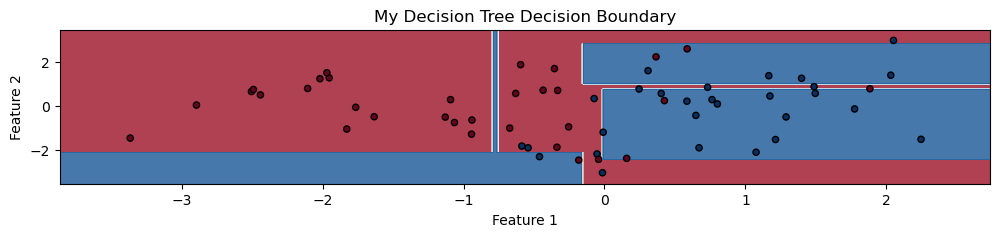

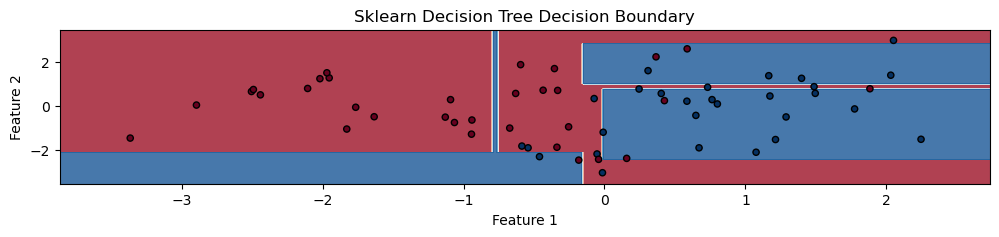

In [8]:
def plot_decision_boundary(X, y, model, title):
    plt.figure(figsize=(12, 2))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Визуализация границ решений для вашей модели
plot_decision_boundary(X_test, y_test, my_tree, 'My Decision Tree Decision Boundary')

# Визуализация границ решений для модели Sklearn
plot_decision_boundary(X_test, y_test, sklearn_tree, 'Sklearn Decision Tree Decision Boundary')
